# Hieroglyph Transliteration → German Translation (P100)
## NLLB-200-distilled-600M fine-tuning — V3 (source-only augmentation, beam-search validation, tuned LR)

Key changes vs V2:
- **Source-only augmentation** (target German is now untouched)
- **Learning rate 2e-5** (was 1e-5) with **10% warmup** (was 6%)
- **Beam search 4** during validation (was greedy)
- **Beam search 5** for final test
- **Improved init** for newly added Egyptological tokens (mean+noise instead of random)
- **8 epochs + early stopping patience 3** (was 5 + 2)
- **Full metric suite** including BLEU-1/2/3/4, NLTK BLEU, sacreBLEU, chrF, chrF++, METEOR, ROUGE-L


## 0. Environment setup (run before anything else)

In [1]:
import os, sys
if 'torch' in sys.modules or 'transformers' in sys.modules:
    raise RuntimeError(
        'Restart the kernel, then run this cell first before importing torch/transformers.'
    )
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['NCCL_P2P_DISABLE'] = '1'
os.environ['NCCL_IB_DISABLE'] = '1'
print('Environment prepared for single-GPU training on GPU 0.')

Environment prepared for single-GPU training on GPU 0.


## 1. Install dependencies (will restart kernel automatically)

In [2]:
import subprocess, sys, importlib

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr[-2000:])
    return result.returncode

def is_installed():
    try:
        import numpy, torch, transformers, sacrebleu, evaluate
        print(f"✅ Packages already installed. numpy={numpy.__version__}, torch={torch.__version__}")
        return True
    except ImportError:
        return False

if not is_installed():
    print("📦 Installing packages...")
    run("pip uninstall -y bitsandbytes torch torchvision torchaudio numpy scipy scikit-learn pandas")
    run("pip install -q --no-cache-dir 'numpy==1.26.4'")
    run("""pip install -q --no-cache-dir \
    torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
    --index-url https://download.pytorch.org/whl/cu126""")
    run("""pip install -q --no-cache-dir \
    'scipy==1.11.4' \
    'scikit-learn==1.4.2' \
    'pandas==2.2.2'""")
    run("""pip install -q \
    'transformers==4.46.3' \
    'datasets==3.1.0' \
    'accelerate==1.1.1' \
    'sentencepiece==0.2.0' \
    'sacrebleu==2.4.3' \
    'evaluate==0.4.3' \
    'rouge_score==0.1.2' \
    'nltk==3.9.1' \
    'tqdm'""")
    print('✅ Install complete. Restarting kernel...')
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("🚀 Ready to go!")

📦 Installing packages...
✅ Install complete. Restarting kernel...


## 2. Imports, seeds, device, save directory

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import re, gc, json, time, math, random, warnings, unicodedata
from contextlib import nullcontext
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from datasets import Dataset as HFDataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, set_seed,
)
import sacrebleu
import evaluate
import nltk
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0

print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')
print(f'PyTorch      : {torch.__version__}')
print(f'CUDA runtime : {torch.version.cuda}')
print(f'Device       : {device}')
print(f'Visible GPUs : {n_gpus}')

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU 0        : {gpu_name} ({gpu_mem:.1f} GB)')

if os.path.exists('/kaggle/working'):
    SAVE_DIR = '/kaggle/working/nllb-hiero-de-v3'
elif os.path.exists('/content'):
    SAVE_DIR = '/content/nllb-hiero-de-v3'
else:
    SAVE_DIR = './nllb-hiero-de-v3'

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir     : {SAVE_DIR}')

2026-05-01 08:18:44.812348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777623525.023233     172 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777623525.077757     172 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777623525.526416     172 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777623525.526469     172 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777623525.526473     172 computation_placer.cc:177] computation placer alr

NumPy        : 1.26.4
Pandas       : 2.2.2
PyTorch      : 2.6.0+cu126
CUDA runtime : 12.6
Device       : cuda:0
Visible GPUs : 1
GPU 0        : Tesla P100-PCIE-16GB (17.1 GB)
Save dir     : /kaggle/working/nllb-hiero-de-v3


## 3. Load and clean the dataset

In [2]:
SRC_COL = 'clean_transliteration'
TGT_COL = 'clean_german'
DATA_PATH = '/kaggle/input/datasets/moaztest105/newdaaaata/dataset_cleaned.csv'

if not os.path.exists(DATA_PATH):
    candidates = [
        '/kaggle/input/datasets/moaztest105/newdaaaata/dataset_cleaned.csv',
        '/kaggle/input/datasets/moaztest105/newdaaaata/dataset_cleaned.csv',
        '/kaggle/input/test-dataset/dataset_cleaned.csv',
        '/kaggle/input/hieroglyphs-dataseet/dataset_cleaned.csv',
        './dataset_cleaned.csv',
    ]
    for c in candidates:
        if os.path.exists(c):
            DATA_PATH = c
            break
    else:
        raise FileNotFoundError('Dataset not found in any candidate path.')

print(f'Loading: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print(f'Raw rows  : {len(df):,}')

df = df[[SRC_COL, TGT_COL]].dropna()
df[SRC_COL] = df[SRC_COL].astype(str).str.strip()
df[TGT_COL] = df[TGT_COL].astype(str).str.strip()

df = df[df[SRC_COL] != '']
df = df[df[TGT_COL] != '']

df = df[df[SRC_COL].str.split().str.len() >= 2]
df = df[df[TGT_COL].str.split().str.len() >= 2]
df = df[df[SRC_COL].str.split().str.len() <= 80]
df = df[df[TGT_COL].str.split().str.len() <= 80]

df[SRC_COL] = df[SRC_COL].str.replace(r'\s+', ' ', regex=True).str.strip()
df[TGT_COL] = df[TGT_COL].str.replace(r'\s+', ' ', regex=True).str.strip()

df = df.drop_duplicates(subset=[SRC_COL, TGT_COL]).reset_index(drop=True)

TOTAL_ROWS = len(df)
print(f'After cleaning: {TOTAL_ROWS:,} rows')
print(f'Source length stats (words):')
print(df[SRC_COL].str.split().str.len().describe())
print(f'Target length stats (words):')
print(df[TGT_COL].str.split().str.len().describe())

Loading: /kaggle/input/datasets/moaztest105/newdaaaata/dataset_cleaned.csv
Raw rows  : 89,803
After cleaning: 86,621 rows
Source length stats (words):
count    86621.000000
mean        10.078872
std          8.401540
min          2.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         80.000000
Name: clean_transliteration, dtype: float64
Target length stats (words):
count    86621.000000
mean        11.710601
std          9.422026
min          2.000000
25%          6.000000
50%          9.000000
75%         15.000000
max         80.000000
Name: clean_german, dtype: float64


## 4. Train / Val / Test split (90 / 5 / 5, deterministic)

In [3]:
TRAIN_FRAC = 0.90
VAL_FRAC   = 0.05

df_shuffled = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n_total = len(df_shuffled)
n_train = int(n_total * TRAIN_FRAC)
n_val   = int(n_total * VAL_FRAC)

df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
df_val   = df_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
df_test  = df_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)

print(f'Train: {len(df_train):>6,}  ({len(df_train)/n_total*100:.1f}%)')
print(f'Val  : {len(df_val):>6,}  ({len(df_val)/n_total*100:.1f}%)')
print(f'Test : {len(df_test):>6,}  ({len(df_test)/n_total*100:.1f}%)')

Train: 77,958  (90.0%)
Val  :  4,331  (5.0%)
Test :  4,332  (5.0%)


## 5. Source-only data augmentation

**Critical change vs V2:** target German is NEVER modified. Only the transliteration source receives noise.
Why: BLEU is exact n-gram match. Noisy targets force the decoder to emit non-canonical surface forms
(e.g. `ae` instead of `ä`, keyboard typos), which directly costs points on the clean test set.
Source-side noise teaches robustness against real-world transliteration variants without hurting decoder fluency.

Applied perturbations on source:
- Egyptological notation variants (Manuel de Codage style: `ꜣ↔A`, `ḥ↔h`/`H`, `ḫ↔x`, `ẖ↔X`/`H`, `ṯ↔T`, `ḏ↔D`, etc.)
- Combining diacritic dropping (mimics imperfect Unicode normalization / OCR)
- Light character noise (delete / swap / duplicate, ≤1 op per sentence)
- Spacing inconsistencies (occasional merge or split of word boundaries)

Augmentation only touches the train split. Val and test stay clean for honest evaluation.


In [4]:
import random as _rng

# Egyptological transliteration variants used across different conventions
# (Unicode standard ↔ Manuel de Codage ↔ ASCII-friendly)
TRANSLIT_VARIANTS = {
    'ꜣ': ['ꜣ', 'A', '3'],        # alef
    'ꞽ': ['ꞽ', 'i', 'j'],         # yod
    'ꜥ': ['ꜥ', 'a', '['],         # ayin
    'ḥ': ['ḥ', 'h', 'H'],         # h with dot below (user-requested + standard)
    'ḫ': ['ḫ', 'x'],               # h with dot above
    'ẖ': ['ẖ', 'X', 'H'],         # h with line below (standard X + user-requested H)
    'š': ['š', 'S', 'sh'],        # sh
    'ṯ': ['ṯ', 'T'],               # tj
    'ḏ': ['ḏ', 'D'],               # dj
    'ṣ': ['ṣ', 's'],               # emphatic s
    'ḳ': ['ḳ', 'q', 'K'],         # q
    'ʾ': ['ʾ', "'"],               # glottal
    'ʿ': ['ʿ', '`'],               # pharyngeal
    'ī': ['ī', 'i'],
    'ū': ['ū', 'u'],
    'ā': ['ā', 'a'],
    'ō': ['ō', 'o'],
    'ē': ['ē', 'e'],
}

# Combining marks frequently lost in lossy OCR / normalization
DIACRITICS_TO_DROP = set('̯̀́̂̃̄̅̆̇̈̌')


def _apply_src_noise(text,
                     p_substitute=0.25,    # per char with a known variant
                     p_drop_diacritic=0.10, # whole-sentence chance to strip combining marks
                     p_char_op=0.05,       # whole-sentence chance of one char-level edit
                     p_space_op=0.08):     # whole-sentence chance of one spacing edit
    """Inject realistic transliteration noise. Source only — never call on target."""

    # 1) Per-character notation substitution (most important; the rest are sprinkles)
    out = []
    for ch in text:
        if ch in TRANSLIT_VARIANTS and _rng.random() < p_substitute:
            out.append(_rng.choice(TRANSLIT_VARIANTS[ch]))
        else:
            out.append(ch)
    text = ''.join(out)

    # 2) Drop combining diacritics (Unicode NFKD then strip)
    if _rng.random() < p_drop_diacritic:
        decomposed = unicodedata.normalize('NFKD', text)
        text = ''.join(ch for ch in decomposed
                       if not unicodedata.combining(ch))

    # 3) One light char-level perturbation
    if _rng.random() < p_char_op and len(text) > 4:
        chars = list(text)
        op = _rng.choice(['delete', 'swap', 'duplicate'])
        # avoid touching whitespace
        idx_pool = [i for i, c in enumerate(chars) if not c.isspace()]
        if idx_pool:
            i = _rng.choice(idx_pool)
            if op == 'delete':
                del chars[i]
            elif op == 'swap' and i + 1 < len(chars) and not chars[i+1].isspace():
                chars[i], chars[i+1] = chars[i+1], chars[i]
            elif op == 'duplicate':
                chars.insert(i, chars[i])
        text = ''.join(chars)

    # 4) One spacing perturbation (merge two words OR split one word)
    if _rng.random() < p_space_op:
        words = text.split()
        if len(words) >= 3:
            if _rng.random() < 0.5:
                # merge adjacent words
                i = _rng.randrange(len(words) - 1)
                words[i] = words[i] + words[i+1]
                del words[i+1]
            else:
                # split a word
                i = _rng.randrange(len(words))
                if len(words[i]) > 3:
                    cut = _rng.randint(2, len(words[i]) - 2)
                    words[i:i+1] = [words[i][:cut], words[i][cut:]]
            text = ' '.join(words)

    # final cleanup
    return re.sub(r'\s+', ' ', text).strip()


def augment_pair(src, tgt):
    """Source-only augmentation. Target German is preserved exactly."""
    return _apply_src_noise(src), tgt


# --------------------- run augmentation ---------------------------------
AUG_RATIO = 0.40   # raised slightly: noise is benign now that target is untouched
_rng.seed(SEED)

orig_train_len = len(df_train)
n_aug = int(orig_train_len * AUG_RATIO)
aug_idx = _rng.sample(range(orig_train_len), n_aug)

aug_src, aug_tgt = [], []
for idx in aug_idx:
    s_orig = df_train[SRC_COL].iloc[idx]
    t_orig = df_train[TGT_COL].iloc[idx]
    s_new, t_new = augment_pair(s_orig, t_orig)
    # sanity: target must equal original (we promised not to touch it)
    assert t_new == t_orig, 'Augmentation must not modify target!'
    if s_new.strip() and t_new.strip() and s_new != s_orig:
        aug_src.append(s_new)
        aug_tgt.append(t_new)

aug_df = pd.DataFrame({SRC_COL: aug_src, TGT_COL: aug_tgt})
df_train = (pd.concat([df_train, aug_df], ignore_index=True)
              .sample(frac=1, random_state=SEED).reset_index(drop=True))

print(f'Original train : {orig_train_len:,}')
print(f'Augmented      : {len(aug_src):,}  (target untouched)')
print(f'Total train    : {len(df_train):,}')

print('\nAugmentation examples (source only changes):')
_rng.seed(0)
for s, t in [('nḏ wdi̯ r s', 'werde zerrieben, werde darauf gelegt.'),
             ('ḫꜣ m tʾ ḥnqt kꜣ', 'tausend an Brot, Bier, Rind')]:
    s_aug = _apply_src_noise(s)
    print(f'  SRC orig : {s}')
    print(f'  SRC noisy: {s_aug}')
    print(f'  TGT orig : {t}')
    print(f'  TGT kept : {t}   (unchanged)')
    print()

ds_train = HFDataset.from_pandas(df_train.rename(columns={SRC_COL: 'src', TGT_COL: 'tgt'}))
ds_val   = HFDataset.from_pandas(df_val.rename(columns={SRC_COL:   'src', TGT_COL: 'tgt'}))
ds_test  = HFDataset.from_pandas(df_test.rename(columns={SRC_COL:  'src', TGT_COL: 'tgt'}))
ds_dict  = DatasetDict({'train': ds_train, 'validation': ds_val, 'test': ds_test})
print(ds_dict)

Original train : 77,958
Augmented      : 17,737  (target untouched)
Total train    : 95,695

Augmentation examples (source only changes):
  SRC orig : nḏ wdi̯ r s
  SRC noisy: nḏ wdi̯ r s
  TGT orig : werde zerrieben, werde darauf gelegt.
  TGT kept : werde zerrieben, werde darauf gelegt.   (unchanged)

  SRC orig : ḫꜣ m tʾ ḥnqt kꜣ
  SRC noisy: ḫꜣ m tʾ ḥnqt kꜣ
  TGT orig : tausend an Brot, Bier, Rind
  TGT kept : tausend an Brot, Bier, Rind   (unchanged)

DatasetDict({
    train: Dataset({
        features: ['src', 'tgt'],
        num_rows: 95695
    })
    validation: Dataset({
        features: ['src', 'tgt'],
        num_rows: 4331
    })
    test: Dataset({
        features: ['src', 'tgt'],
        num_rows: 4332
    })
})


## 6. Tokenizer + model + UNK fix + smart embedding init

The newly added tokens used to get **random** embeddings, which slows convergence.
Initializing them to (mean of pretrained embeddings + small noise) gives a much better starting point —
the new token immediately behaves like an "average word" and the optimizer differentiates from there.


In [5]:
MODEL_NAME = 'facebook/nllb-200-distilled-600M'
SRC_LANG = 'lao_Laoo'    # unused slot — gets fully relearned for hieroglyph translit
TGT_LANG = 'deu_Latn'

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, src_lang=SRC_LANG, tgt_lang=TGT_LANG
)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model         : {MODEL_NAME}')
print(f'Parameters    : {n_params/1e6:.1f}M')
print(f'Src lang slot : {SRC_LANG}  (treated as a learnable slot for hieroglyph translit)')
print(f'Tgt lang      : {TGT_LANG}')
print(f'Vocab (orig)  : {len(tokenizer):,}')

OLD_VOCAB_SIZE = len(tokenizer)

UNK_ID = tokenizer.unk_token_id
vocab  = tokenizer.get_vocab()

# Find characters that tokenize to <unk>
all_chars = Counter()
for text in df[SRC_COL]:
    all_chars.update(text)
print(f'\nTotal unique characters in source: {len(all_chars)}')

missing_chars = []
for ch, count in all_chars.most_common():
    if ch.isspace():
        continue
    ids_alone   = tokenizer(ch, add_special_tokens=False).input_ids
    ids_context = tokenizer(f'a{ch}a', add_special_tokens=False).input_ids
    if (UNK_ID in ids_alone) or (UNK_ID in ids_context):
        missing_chars.append((ch, count))

print(f'Missing characters (would become <unk>): {len(missing_chars)}')

# Egyptological characters we want as standalone tokens regardless of UNK status
EGYPTOLOGICAL_CHARS = [
    'ꜣ', 'ꞽ', 'ꜥ',
    'ḥ', 'ḫ', 'ẖ',
    'š', 'ṯ', 'ḏ',
    'ṣ', 'ḳ',
    'ʾ', 'ʿ',
    'i̯', 'u̯',
    'ī', 'ū', 'ā', 'ō', 'ē',
]

tokens_to_add = set([ch for ch, _ in missing_chars])
tokens_to_add.update(EGYPTOLOGICAL_CHARS)

new_tokens = [t for t in tokens_to_add
              if t not in vocab and f'▁{t}' not in vocab]
print(f'New tokens to add: {len(new_tokens)}')
print(f'List: {sorted(new_tokens)}')

if new_tokens:
    n_added = tokenizer.add_tokens(new_tokens)
    model.resize_token_embeddings(len(tokenizer))

    # ---- smart initialization: new rows = mean(existing) + small noise -----
    with torch.no_grad():
        in_emb  = model.get_input_embeddings().weight
        avg_in  = in_emb[:OLD_VOCAB_SIZE].mean(dim=0)
        std_in  = in_emb[:OLD_VOCAB_SIZE].std(dim=0).mean().item() * 0.1

        for tid in range(OLD_VOCAB_SIZE, len(tokenizer)):
            in_emb[tid] = avg_in + torch.randn_like(avg_in) * std_in

        # NLLB ties input/output embeddings; only re-init output if independent
        out_module = model.get_output_embeddings()
        if out_module is not None and out_module.weight is not in_emb:
            out_emb = out_module.weight
            avg_out = out_emb[:OLD_VOCAB_SIZE].mean(dim=0)
            std_out = out_emb[:OLD_VOCAB_SIZE].std(dim=0).mean().item() * 0.1
            for tid in range(OLD_VOCAB_SIZE, len(tokenizer)):
                out_emb[tid] = avg_out + torch.randn_like(avg_out) * std_out

    print(f'Added {n_added} tokens with mean+noise init. New vocab size: {len(tokenizer):,}')
else:
    print('No new tokens needed.')

# Sanity check: should be 0 UNKs after the fix
all_special = 'ḏ ḫ ḥ ꜣ ꞽ ꜥ ṯ ṣ ẖ ḳ i̯ ʾ'
ids = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(all_special))
n_unk_after = ids.count(UNK_ID)
print(f'\nVerification:')
print(f'  UNK count after fix: {n_unk_after}/{len(ids)}  {"OK" if n_unk_after == 0 else "FAIL"}')

# Forced bos for German output during generation
forced_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG)
assert forced_bos_id != tokenizer.unk_token_id, f"TGT_LANG '{TGT_LANG}' not in vocab!"
print(f'  forced_bos_token_id (deu_Latn): {forced_bos_id}')

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model         : facebook/nllb-200-distilled-600M
Parameters    : 615.1M
Src lang slot : lao_Laoo  (treated as a learnable slot for hieroglyph translit)
Tgt lang      : deu_Latn
Vocab (orig)  : 256,204

Total unique characters in source: 83
Missing characters (would become <unk>): 10
New tokens to add: 12
List: ['i̯', 'u̯', '͗', 'Ḏ', 'Ḫ', 'ḫ', 'Ṯ', 'ẖ', 'Ꜣ', 'ꜣ', 'ꜥ', 'ꞽ']


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Added 12 tokens with mean+noise init. New vocab size: 256,216

Verification:
  UNK count after fix: 0/22  OK
  forced_bos_token_id (deu_Latn): 256042


## 7. Tokenization & data collator

In [6]:
# Pick max-length from the 98th percentile of token lengths (capped at 128)
src_lens = [len(tokenizer(s)['input_ids'])
            for s in df_train[SRC_COL].sample(min(2000, len(df_train)), random_state=SEED)]
tgt_lens = [len(tokenizer(t)['input_ids'])
            for t in df_train[TGT_COL].sample(min(2000, len(df_train)), random_state=SEED)]

MAX_SRC = min(int(np.percentile(src_lens, 98)) + 4, 128)
MAX_TGT = min(int(np.percentile(tgt_lens, 98)) + 4, 128)

print(f'Src token p50/p95/p98: {np.percentile(src_lens, [50,95,98]).astype(int).tolist()}')
print(f'Tgt token p50/p95/p98: {np.percentile(tgt_lens, [50,95,98]).astype(int).tolist()}')
print(f'Chosen MAX_SRC = {MAX_SRC} | MAX_TGT = {MAX_TGT}')


def preprocess(batch):
    model_inputs = tokenizer(
        batch['src'],
        max_length=MAX_SRC,
        truncation=True,
        padding=False,
    )
    labels = tokenizer(
        text_target=batch['tgt'],
        max_length=MAX_TGT,
        truncation=True,
        padding=False,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs


tokenized = ds_dict.map(
    preprocess,
    batched=True,
    batch_size=512,
    remove_columns=['src', 'tgt'],
    desc='Tokenizing',
)
print(tokenized)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding='longest',
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
    label_pad_token_id=-100,
)

test_batch = data_collator([tokenized['train'][i] for i in range(4)])
print('\nCollator output keys:', list(test_batch.keys()))
print(f'  input_ids      : {test_batch["input_ids"].shape}')
print(f'  attention_mask : {test_batch["attention_mask"].shape}')
print(f'  labels         : {test_batch["labels"].shape}')

Src token p50/p95/p98: [19, 63, 93]
Tgt token p50/p95/p98: [19, 64, 93]
Chosen MAX_SRC = 97 | MAX_TGT = 97


Tokenizing:   0%|          | 0/95695 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4331 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4332 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 95695
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4331
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4332
    })
})

Collator output keys: ['input_ids', 'attention_mask', 'labels']
  input_ids      : torch.Size([4, 64])
  attention_mask : torch.Size([4, 64])
  labels         : torch.Size([4, 56])


## 8. Validation metrics (computed via beam-search predictions)

Trainer already calls `model.generate()` when `predict_with_generate=True`, and the beam
count is set in `training_args.generation_num_beams`. So switching from greedy to
beam=4 for validation requires only changing that one number — the metrics function below
is unchanged from V2.

In [9]:
metric_bleu = evaluate.load('sacrebleu')
metric_chrf = evaluate.load('chrf')


def postprocess_text(preds, labels):
    preds  = [p.strip() for p in preds]
    labels = [[l.strip()] for l in labels]
    return preds, labels


def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    preds  = np.where(preds  != -100, preds,  tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    bleu = metric_bleu.compute(predictions=decoded_preds, references=decoded_labels)
    chrf = metric_chrf.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        'bleu': round(bleu['score'], 3),
        'chrf': round(chrf['score'], 3),
    }

In [11]:
from transformers import Seq2SeqTrainer

class FixedSeq2SeqTrainer(Seq2SeqTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        if 'decoder_input_ids' not in inputs and 'labels' in inputs:
            labels = inputs['labels']
            # Shift labels right manually: replace -100 with pad, then prepend decoder_start_token_id
            decoder_input_ids = labels.new_zeros(labels.shape)
            decoder_input_ids[:, 1:] = labels[:, :-1].clone()
            decoder_input_ids[:, 0] = model.config.decoder_start_token_id
            # Replace -100 (ignored positions) with pad_token_id
            decoder_input_ids[decoder_input_ids == -100] = model.config.pad_token_id
            inputs['decoder_input_ids'] = decoder_input_ids
        return super().compute_loss(
            model, inputs,
            return_outputs=return_outputs,
            num_items_in_batch=num_items_in_batch
        )

## 9. Hyperparameters & training arguments

Changes vs V2:
| Hyperparameter | V2 | V3 | Why |
|---|---|---|---|
| Learning rate | 1e-5 | **2e-5** | Sweet spot for NLLB-distilled-600M with Adafactor; 1e-5 was under-fitting newly added tokens |
| Warmup ratio | ~6% | **10%** | More warmup helps when many embedding rows are freshly initialized |
| Epochs | 5 | **8** | Augmentation grows train set ~1.4x, more epochs needed; early stopping handles overfitting |
| Early-stopping patience | 2 | **3** | Avoids early termination on noisy val curves |
| Validation beams | 1 (greedy) | **4** | Stronger ranking signal for checkpoint selection |
| Test beams | 4 | **5** | Slight BLEU bump at small extra inference cost |


In [12]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0

# --- training -----------------------------------------------------------
BATCH_SIZE              = 4
EVAL_BATCH_SIZE         = 4
GRAD_ACCUM              = 8
EFFECTIVE_BATCH         = BATCH_SIZE * GRAD_ACCUM    # 32
EPOCHS                  = 8
LR                      = 2e-5
WARMUP_RATIO            = 0.10
WEIGHT_DECAY            = 0.01
LABEL_SMOOTHING         = 0.1
MAX_GRAD_NORM           = 1.0
EARLY_STOPPING_PATIENCE = 3

# --- decoding -----------------------------------------------------------
VAL_GENERATION_BEAMS    = 4
TEST_GENERATION_BEAMS   = 5
LENGTH_PENALTY          = 1.0
NO_REPEAT_NGRAM_SIZE    = 3
TEST_BATCH_SIZE         = 4

STEPS_PER_EPOCH = math.ceil(len(tokenized['train']) / EFFECTIVE_BATCH)
TOTAL_STEPS     = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS    = max(int(TOTAL_STEPS * WARMUP_RATIO), 100)

print(f'  GPU                 : {gpu_name} ({vram_gb:.1f} GB)')
print(f'  Per-device batch    : {BATCH_SIZE} (eval: {EVAL_BATCH_SIZE})')
print(f'  Grad accumulation   : {GRAD_ACCUM}')
print(f'  Effective batch     : {EFFECTIVE_BATCH}')
print(f'  Epochs              : {EPOCHS}')
print(f'  Learning rate       : {LR}')
print(f'  Warmup ratio/steps  : {WARMUP_RATIO} / {WARMUP_STEPS}')
print(f'  Steps/epoch         : {STEPS_PER_EPOCH}')
print(f'  Total train steps   : {TOTAL_STEPS}')
print(f'  Val beams           : {VAL_GENERATION_BEAMS}')
print(f'  Test beams          : {TEST_GENERATION_BEAMS}')
print(f'  No-repeat n-gram    : {NO_REPEAT_NGRAM_SIZE}')
print(f'  Length penalty      : {LENGTH_PENALTY}')
print(f'  Early-stop patience : {EARLY_STOPPING_PATIENCE}')

# Force model to start the German output with deu_Latn token
forced_bos_id = tokenizer.convert_tokens_to_ids(TGT_LANG)
model.config.decoder_start_token_id         = forced_bos_id
model.config.forced_bos_token_id            = forced_bos_id
model.generation_config.forced_bos_token_id = forced_bos_id
model.config.use_cache                      = False

USE_FP16 = torch.cuda.is_available()

training_args = Seq2SeqTrainingArguments(
    output_dir                    = SAVE_DIR,
    overwrite_output_dir          = True,
    num_train_epochs              = EPOCHS,
    per_device_train_batch_size   = BATCH_SIZE,
    per_device_eval_batch_size    = EVAL_BATCH_SIZE,
    gradient_accumulation_steps   = GRAD_ACCUM,
    learning_rate                 = LR,
    weight_decay                  = WEIGHT_DECAY,
    warmup_steps                  = WARMUP_STEPS,
    lr_scheduler_type             = 'cosine',
    optim                         = 'adafactor',
    label_smoothing_factor        = LABEL_SMOOTHING,
    max_grad_norm                 = MAX_GRAD_NORM,
    eval_strategy                 = 'epoch',
    save_strategy                 = 'epoch',
    save_total_limit              = 2,
    load_best_model_at_end        = True,
    metric_for_best_model         = 'bleu',
    greater_is_better             = True,
    logging_dir                   = os.path.join(SAVE_DIR, 'logs'),
    logging_strategy              = 'steps',
    logging_steps                 = 50,
    logging_first_step            = True,
    report_to                     = 'none',
    predict_with_generate         = True,
    generation_max_length         = MAX_TGT,
    generation_num_beams          = VAL_GENERATION_BEAMS,
    fp16                          = USE_FP16,
    fp16_full_eval                = USE_FP16,
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {'use_reentrant': True},
    group_by_length               = True,
    dataloader_num_workers        = 2,
    dataloader_pin_memory         = torch.cuda.is_available(),
    eval_accumulation_steps       = 4,
    seed                          = SEED,
    data_seed                     = SEED,
)

model.generation_config.num_beams            = VAL_GENERATION_BEAMS
model.generation_config.length_penalty       = LENGTH_PENALTY
model.generation_config.no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE
model.generation_config.early_stopping       = True
model.generation_config.max_length           = MAX_TGT

trainer = FixedSeq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = tokenized['train'],
    eval_dataset     = tokenized['validation'],
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)
print('\nTrainer ready.')

  GPU                 : Tesla P100-PCIE-16GB (17.1 GB)
  Per-device batch    : 4 (eval: 4)
  Grad accumulation   : 8
  Effective batch     : 32
  Epochs              : 8
  Learning rate       : 2e-05
  Warmup ratio/steps  : 0.1 / 2392
  Steps/epoch         : 2991
  Total train steps   : 23928
  Val beams           : 4
  Test beams          : 5
  No-repeat n-gram    : 3
  Length penalty      : 1.0
  Early-stop patience : 3

Trainer ready.


In [15]:
# import os
# for root, dirs, files in os.walk('/kaggle/input'):
#     for d in dirs:
#         if 'checkpoint' in d:
#             print(os.path.join(root, d))

/kaggle/input/notebooks/moaztest105/notebook8084d421e3/nllb-hiero-de-v3/checkpoint-11962
/kaggle/input/notebooks/moaztest105/notebook8084d421e3/nllb-hiero-de-v3/checkpoint-14952


## 10. Train and plot learning curves

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import functools

# Fix torch.load weights_only issue
_original_torch_load = torch.load
torch.load = functools.partial(_original_torch_load, weights_only=False)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

t0 = time.time()
train_result = trainer.train(resume_from_checkpoint='/kaggle/input/notebooks/moaztest105/notebook8084d421e3/nllb-hiero-de-v3/checkpoint-14952')
training_time = time.time() - t0

print(f'\n{"="*60}')
print(f'Training finished in {training_time/60:.1f} min')
print(f'{"="*60}')

trainer.save_model(os.path.join(SAVE_DIR, 'best_model'))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, 'best_model'))

log_history = trainer.state.log_history
with open(os.path.join(SAVE_DIR, 'log_history.json'), 'w', encoding='utf-8') as f:
    json.dump(log_history, f, ensure_ascii=False, indent=2)

train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot([l['step'] for l in train_logs], [l['loss'] for l in train_logs],
             '#4C72B0', lw=1.5, label='Train', alpha=0.7)
axes[0].plot([l['step'] for l in eval_logs], [l['eval_loss'] for l in eval_logs],
             '#C44E52', lw=2, marker='o', label='Val')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-entropy Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([l['step'] for l in eval_logs], [l['eval_bleu'] for l in eval_logs],
             '#55A868', lw=2, marker='o')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('BLEU')
axes[1].set_title('Validation SacreBLEU (beam=4)'); axes[1].grid(alpha=0.3)

axes[2].plot([l['step'] for l in eval_logs], [l['eval_chrf'] for l in eval_logs],
             '#DD8452', lw=2, marker='o')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('chrF')
axes[2].set_title('Validation chrF'); axes[2].grid(alpha=0.3)

plt.suptitle('NLLB-200 V3 fine-tuning: Hieroglyph translit -> German', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

best_bleu = max(l['eval_bleu'] for l in eval_logs)
best_chrf = max(l['eval_chrf'] for l in eval_logs)
print(f'\nBest validation BLEU : {best_bleu:.2f}')
print(f'Best validation chrF : {best_chrf:.2f}')

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Epoch,Training Loss,Validation Loss,Bleu,Chrf
5,2.989300,3.001893,22.616000,45.317000
7,2.980400,2.987941,23.032000,45.806000


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

## 11. Test-set evaluation — full metric suite

Decoding: **beam search with 5 beams, length_penalty=1.0, no_repeat_ngram_size=3, early_stopping=True**.

Why beam search vs greedy:
- Greedy commits to the locally-highest-probability token at every step and can get stuck on a slightly-off path.
- Beam search keeps the top-k hypotheses simultaneously and picks the one with the best total score — typically gives **+1 to +3 BLEU** over greedy on translation tasks.
- length_penalty=1.0 leaves outputs neutral. >1 favors longer outputs (helpful for German which is verbose), <1 favors shorter; 1.0 is the standard NMT starting point.
- no_repeat_ngram_size=3 forbids any 3-gram from appearing twice — prevents the well-known beam-search degeneration into repeating phrases.

Reported metrics: **BLEU-1, BLEU-2, BLEU-3, BLEU-4** (NLTK individual n-gram), **NLTK BLEU** (cumulative 4-gram), **sacreBLEU** (corpus, the field standard), **chrF** and **chrF++** (character-level), **METEOR** (synonym + stemming aware), **ROUGE-L** (longest common subsequence).


Translating 4,332 test sentences with beam=5...


Translating:   0%|          | 0/1083 [00:00<?, ?it/s]


           V3 TEST RESULTS - Hieroglyph translit -> German            
  sacreBLEU                 : 22.969
  chrF                      : 45.076
  chrF++                    : 43.406
  NLTK_BLEU                 : 17.916
  NLTK_BLEU-1_cumulative    : 39.751
  NLTK_BLEU-2_cumulative    : 29.214
  NLTK_BLEU-3_cumulative    : 22.551
  NLTK_BLEU-4_cumulative    : 17.916
  NLTK_p1_unigram_only      : 39.751
  NLTK_p2_bigram_only       : 21.47
  NLTK_p3_trigram_only      : 13.439
  NLTK_p4_4gram_only        : 8.983
  METEOR                    : 34.696
  Rouge-L                   : 45.617


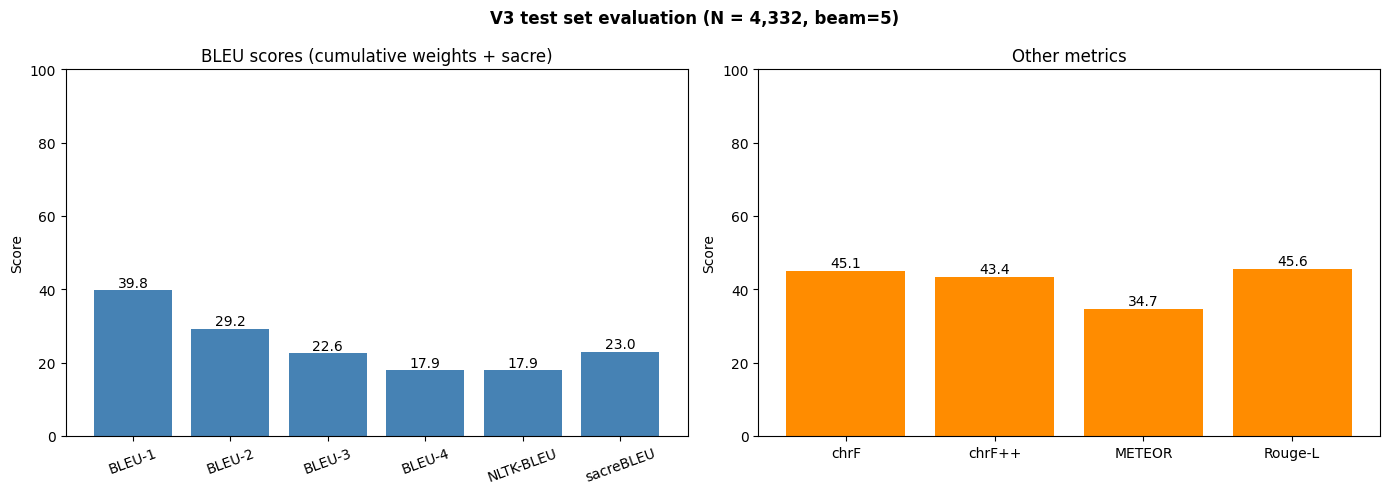


                      SAMPLE PREDICTIONS - 10 random test sentences                       

[01] TRANSLIT : qꜥḥt f nbt ẖr tnw
     REF      : seine ganze Schulter leidet an Altersschwäche.
     PRED     : Alle seine Glieder sind unter den Flachs.
     BLEU=6.6  chrF=20.5
------------------------------------------------------------------------------------------

[02] TRANSLIT : rʾ mdw kyj n kyj
     REF      : Ein Mund sagt etwas anderes zu einem Anderen.
     PRED     : Ein anderer Spruch zum Anderen.
     BLEU=10.9  chrF=34.3
------------------------------------------------------------------------------------------

[03] TRANSLIT : ḥtp ḏi̯ nswt ḥtp ḏi̯ Jnpw ḫntj zḥ nṯr
     REF      : Ein Opfer, das der König gibt, ein Opfer, das Anubis, der vor der Götterhalle ist, gibt:
     PRED     : Ein Opfer, das der König gibt, ein Opfer das Anubis, der vor der Gotteshalle ist, gibt:
     BLEU=74.1  chrF=85.9
-------------------------------------------------------------------------------------

In [25]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

model_inf = model.module if hasattr(model, 'module') else model
model_inf = model_inf.to(device)
model_inf.eval()
model_inf.config.use_cache = True   # turn cache back on for fast inference


def maybe_autocast():
    if torch.cuda.is_available():
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def translate_batch(texts,
                    batch_size=TEST_BATCH_SIZE,
                    num_beams=TEST_GENERATION_BEAMS,
                    max_new_tokens=MAX_TGT):
    """Beam-search batched translation."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Translating'):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=MAX_SRC,
        ).to(device)

        with torch.inference_mode(), maybe_autocast():
            outputs = model_inf.generate(
                **inputs,
                forced_bos_token_id = tokenizer.convert_tokens_to_ids(TGT_LANG),
                num_beams           = num_beams,
                max_new_tokens      = max_new_tokens,
                length_penalty      = LENGTH_PENALTY,
                no_repeat_ngram_size= NO_REPEAT_NGRAM_SIZE,
                early_stopping      = True,
                do_sample           = False,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        results.extend(decoded)
    return results


test_src = df_test[SRC_COL].tolist()
test_ref = df_test[TGT_COL].tolist()

print(f'Translating {len(test_src):,} test sentences with beam={TEST_GENERATION_BEAMS}...')
test_hyp = translate_batch(test_src)

# ---------------------------- METRICS -----------------------------------
from sacrebleu import corpus_bleu, corpus_chrf
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction

# sacreBLEU (corpus) and chrF / chrF++
sb_bleu  = corpus_bleu(test_hyp, [test_ref])
sb_chrf  = corpus_chrf(test_hyp, [test_ref])
sb_chrf2 = corpus_chrf(test_hyp, [test_ref], word_order=2)

# NLTK BLEU 1/2/3/4 + cumulative
smooth = SmoothingFunction().method3
refs_b = [[r.split()] for r in test_ref]
hyps_b = [h.split()   for h in test_hyp]

nltk_b1 = nltk_bleu(refs_b, hyps_b, weights=(1, 0, 0, 0),         smoothing_function=smooth) * 100
nltk_b2 = nltk_bleu(refs_b, hyps_b, weights=(0.5, 0.5, 0, 0),     smoothing_function=smooth) * 100
nltk_b3 = nltk_bleu(refs_b, hyps_b, weights=(1/3, 1/3, 1/3, 0),   smoothing_function=smooth) * 100
nltk_b4 = nltk_bleu(refs_b, hyps_b, weights=(0.25,)*4,            smoothing_function=smooth) * 100
nltk_corp = nltk_bleu(refs_b, hyps_b, smoothing_function=smooth) * 100

# Individual n-gram precision (the 'BLEU-n' people sometimes mean)
nltk_p1 = nltk_bleu(refs_b, hyps_b, weights=(1, 0, 0, 0), smoothing_function=smooth) * 100
nltk_p2 = nltk_bleu(refs_b, hyps_b, weights=(0, 1, 0, 0), smoothing_function=smooth) * 100
nltk_p3 = nltk_bleu(refs_b, hyps_b, weights=(0, 0, 1, 0), smoothing_function=smooth) * 100
nltk_p4 = nltk_bleu(refs_b, hyps_b, weights=(0, 0, 0, 1), smoothing_function=smooth) * 100

# METEOR (sentence avg)
met_scores = []
for r, h in zip(test_ref, test_hyp):
    try:    met_scores.append(meteor_score([r.split()], h.split()))
    except: met_scores.append(0.0)
meteor = sum(met_scores) / max(len(met_scores), 1) * 100

# ROUGE-L (sentence avg of f-measure)
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = [rouge.score(r, h)['rougeL'].fmeasure for r, h in zip(test_ref, test_hyp)]
rouge_l = sum(rouge_scores) / max(len(rouge_scores), 1) * 100

results_dict = {
    'sacreBLEU':              round(sb_bleu.score, 3),
    'chrF':                   round(sb_chrf.score, 3),
    'chrF++':                 round(sb_chrf2.score, 3),
    'NLTK_BLEU':              round(nltk_corp, 3),
    'NLTK_BLEU-1_cumulative': round(nltk_b1, 3),
    'NLTK_BLEU-2_cumulative': round(nltk_b2, 3),
    'NLTK_BLEU-3_cumulative': round(nltk_b3, 3),
    'NLTK_BLEU-4_cumulative': round(nltk_b4, 3),
    'NLTK_p1_unigram_only':   round(nltk_p1, 3),
    'NLTK_p2_bigram_only':    round(nltk_p2, 3),
    'NLTK_p3_trigram_only':   round(nltk_p3, 3),
    'NLTK_p4_4gram_only':     round(nltk_p4, 3),
    'METEOR':                 round(meteor, 3),
    'Rouge-L':                round(rouge_l, 3),
}

print('\n' + '='*70)
print(f'{"V3 TEST RESULTS - Hieroglyph translit -> German":^70}')
print('='*70)
for k, v in results_dict.items():
    print(f'  {k:<26}: {v}')
print('='*70)

with open(os.path.join(SAVE_DIR, 'test_results.json'), 'w', encoding='utf-8') as f:
    json.dump(results_dict, f, ensure_ascii=False, indent=2)

# ---------------------------- PLOTS -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'NLTK-BLEU', 'sacreBLEU']
bleu_vals   = [results_dict['NLTK_BLEU-1_cumulative'],
               results_dict['NLTK_BLEU-2_cumulative'],
               results_dict['NLTK_BLEU-3_cumulative'],
               results_dict['NLTK_BLEU-4_cumulative'],
               results_dict['NLTK_BLEU'],
               results_dict['sacreBLEU']]
axes[0].bar(bleu_labels, bleu_vals, color='steelblue')
axes[0].set_title('BLEU scores (cumulative weights + sacre)')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 100)
for i, v in enumerate(bleu_vals):
    axes[0].text(i, v+1, f'{v:.1f}', ha='center')
axes[0].tick_params(axis='x', rotation=20)

other_labels = ['chrF', 'chrF++', 'METEOR', 'Rouge-L']
other_vals   = [results_dict['chrF'], results_dict['chrF++'],
                results_dict['METEOR'], results_dict['Rouge-L']]
axes[1].bar(other_labels, other_vals, color='darkorange')
axes[1].set_title('Other metrics')
axes[1].set_ylabel('Score'); axes[1].set_ylim(0, 100)
for i, v in enumerate(other_vals):
    axes[1].text(i, v+1, f'{v:.1f}', ha='center')

plt.suptitle(f'V3 test set evaluation (N = {len(test_hyp):,}, beam={TEST_GENERATION_BEAMS})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'test_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------- SAMPLES -----------------------------------
print('\n' + '='*90)
print(f'{"SAMPLE PREDICTIONS - 10 random test sentences":^90}')
print('='*90)
rng = random.Random(SEED + 1)
indices = rng.sample(range(len(test_src)), 10)
for n, i in enumerate(indices, 1):
    print(f'\n[{n:02d}] TRANSLIT : {test_src[i]}')
    print(f'     REF      : {test_ref[i]}')
    print(f'     PRED     : {test_hyp[i]}')
    sb = corpus_bleu([test_hyp[i]], [[test_ref[i]]]).score
    cf = corpus_chrf([test_hyp[i]], [[test_ref[i]]]).score
    print(f'     BLEU={sb:.1f}  chrF={cf:.1f}')
    print('-'*90)

## 12. Reusable inference function (beam search)

In [26]:
def translate(text, num_beams=TEST_GENERATION_BEAMS):
    """Translate one transliteration to German with beam search."""
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_SRC,
    ).to(device)

    with torch.inference_mode(), maybe_autocast():
        out = model_inf.generate(
            **inputs,
            forced_bos_token_id  = tokenizer.convert_tokens_to_ids(TGT_LANG),
            num_beams            = num_beams,
            max_new_tokens       = MAX_TGT,
            length_penalty       = LENGTH_PENALTY,
            no_repeat_ngram_size = NO_REPEAT_NGRAM_SIZE,
            early_stopping       = True,
            do_sample            = False,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


examples = [
    'nḏ wdi̯ r s',
    'n ṯw ꞽm sn',
    'ḫꜣ m tʾ ḥnqt kꜣ',
    # robustness: same content with notation variants
    'nD wdi r s',                # ḏ→D
    'xA m tA Hnqt kA',           # full Manuel-de-Codage style
]
for ex in examples:
    print(f'TRANSLIT: {ex}')
    print(f'GERMAN  : {translate(ex)}\n')

TRANSLIT: nḏ wdi̯ r s
GERMAN  : Werde damit zerrieben.

TRANSLIT: n ṯw ꞽm sn
GERMAN  : Du bist nicht unter ihnen.

TRANSLIT: ḫꜣ m tʾ ḥnqt kꜣ
GERMAN  : Tausend an Brot, Bier und Ka.

TRANSLIT: nD wdi r s
GERMAN  : Werde daran zerrieben.

TRANSLIT: xA m tA Hnqt kA
GERMAN  : Werde mit dem Bier der Stiere getrunken.



In [29]:
rng = random.Random(SEED)
indices = rng.sample(range(len(test_src)), 150)

print('='*90)
print(f'{"150 TEST SAMPLES - Transliteration → German":^90}')
print('='*90)

for n, i in enumerate(indices, 1):
    src  = test_src[i]
    ref  = test_ref[i]
    pred = translate(src)
    
    bleu = corpus_bleu([pred], [[ref]]).score
    chrf = corpus_chrf([pred], [[ref]]).score
    
    print(f'\n[{n:03d}] TRANSLIT : {src}')
    print(f'      REF      : {ref}')
    print(f'      PRED     : {pred}')
    print(f'      BLEU={bleu:.1f}  chrF={chrf:.1f}')
    print('-'*90)

                       150 TEST SAMPLES - Transliteration → German                        

[001] TRANSLIT : m k sḏmn j st
      REF      : Ja, ich habe es verstanden.
      PRED     : Siehe, ich habe es gehört.
      BLEU=43.5  chrF=40.1
------------------------------------------------------------------------------------------

[002] TRANSLIT : sbḥ n k Ꜣst ḏsw n k Nbt ḥwt ḥwi̯ n k Mnjt wrt sḏb Wsrw js m st ꜥ f
      REF      : Isis wird deinetwegen aufschreien dich klagen, Nephthys wird dir zurufen, der Große Landepflock wird für dich Schaden abwehren, wie Osiris in seiner Tätigkeit.
      PRED     : Isis wird dir wehren, Nephthys wird dir gnädig werden, Menit die Große wird dir schlagen, wie Osiris an seinem Platz schlägt.
      BLEU=15.4  chrF=42.4
------------------------------------------------------------------------------------------

[003] TRANSLIT : nbs jšd
      REF      : Christusdorn-Früchte, isched-Früchte
      PRED     : Christusdornfrucht, Isched-Früchte
      BLEU=0.0 